# Import

In [2]:
# Import der wichtigen Pakete
import os
import re
import json
import gzip
import tarfile
import zipfile
import ast
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from bs4 import BeautifulSoup
import requests
import sqlite3

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans

# Fix für Jupyter Notebook
%matplotlib inline




In [3]:
df = pd.read_csv('200125_LoL_champion_data.csv')

# EDA

In [4]:
# Da dies ein Machine Learning Projekt ist, ist es wichtig, dass wir in den folgenden Abschnitten einen Überblick über die Daten erhalten und die Daten entsprechend vorbereiten.
# Wichtig dabei ist, dass Nullwerte entfernt werden, die Daten in numerische Werte umgewandelt werden und die Daten in Trainings- und Testdaten aufgeteilt werden.
# Der erste Schritt ist es, sich die Daten genauer anzuschauen, um zu sehen, welche Daten vorhanden sind und wie sie aussehen.

In [5]:
df.shape

(172, 33)

In [6]:
df.size

5676

In [7]:
df.head(8)

,Unnamed: 0,id,apiname,title,difficulty,herotype,alttype,resource,stats,rangetype,...,be,rp,skill_i,skill_q,skill_w,skill_e,skill_r,skills,fullname,nickname
0,Aatrox,266.0,Aatrox,the Darkin Blade,2,Fighter,Tank,Blood Well,"{'hp_base': 650, 'hp_lvl': 114, 'mp_base': 0, ...",Melee,...,4800,880,{1: 'Deathbringer Stance'},"{1: 'The Darkin Blade', 2: 'The Darkin Blade 3'}",{1: 'Infernal Chains'},{1: 'Umbral Dash'},{1: 'World Ender'},"{1: 'Deathbringer Stance', 2: 'The Darkin Blad...",NaN,NaN
1,Ahri,103.0,Ahri,the Nine-Tailed Fox,2,Mage,Assassin,Mana,"{'hp_base': 590, 'hp_lvl': 104, 'mp_base': 418...",Ranged,...,3150,790,{1: 'Essence Theft'},{1: 'Orb of Deception'},{1: 'Fox-Fire'},{1: 'Charm'},{1: 'Spirit Rush'},"{1: 'Essence Theft', 2: 'Orb of Deception', 3:...",NaN,NaN
2,Akali,84.0,Akali,the Rogue Assassin,2,Assassin,NaN,Energy,"{'hp_base': 600, 'hp_lvl': 119, 'mp_base': 200...",Melee,...,3150,790,"{1: ""Assassin's Mark""}",{1: 'Five Point Strike'},{1: 'Twilight Shroud'},{1: 'Shuriken Flip'},{1: 'Perfect Execution'},"{1: ""Assassin's Mark"", 2: 'Five Point Strike',...",Akali Jhomen Tethi,NaN
3,Akshan,166.0,Akshan,the Rogue Sentinel,3,Marksman,Assassin,Mana,"{'hp_base': 630, 'hp_lvl': 107, 'mp_base': 350...",Ranged,...,4800,880,{1: 'Dirty Fighting'},{1: 'Avengerang'},{1: 'Going Rogue'},{1: 'Heroic Swing'},{1: 'Comeuppance'},"{1: 'Dirty Fighting', 2: 'Avengerang', 3: 'Goi...",NaN,NaN
4,Alistar,12.0,Alistar,the Minotaur,1,Tank,Support,Mana,"{'hp_base': 685, 'hp_lvl': 120, 'mp_base': 350...",Melee,...,1350,585,{1: 'Triumphant Roar'},{1: 'Pulverize'},{1: 'Headbutt'},{1: 'Trample'},{1: 'Unbreakable Will'},"{1: 'Triumphant Roar', 2: 'Pulverize', 3: 'Hea...",NaN,NaN
5,Ambessa,799.0,Ambessa,The Matriarch of War,3,Fighter,Assassin,Energy,"{'hp_base': 630, 'hp_lvl': 110, 'mp_base': 200...",Melee,...,7800,975,"{1: ""Drakehound's Step""}","{1: 'Cunning Sweep', 2: 'Sundering Slam'}",{1: 'Repudiation'},{1: 'Lacerate'},{1: 'Public Execution'},"{1: ""Drakehound's Step"", 2: 'Cunning Sweep', 3...",Ambessa Medarda,NaN
6,Amumu,32.0,Amumu,the Sad Mummy,1,Tank,Support,Mana,"{'hp_base': 685, 'hp_lvl': 94, 'mp_base': 285,...",Melee,...,450,260,{1: 'Cursed Touch'},{1: 'Bandage Toss'},{1: 'Despair'},{1: 'Tantrum'},{1: 'Curse of the Sad Mummy'},"{1: 'Cursed Touch', 2: 'Bandage Toss', 3: 'Des...",NaN,NaN
7,Anivia,34.0,Anivia,the Cryophoenix,3,Mage,Support,Mana,"{'hp_base': 550, 'hp_lvl': 92, 'mp_base': 495,...",Ranged,...,3150,790,{1: 'Rebirth'},{1: 'Flash Frost'},{1: 'Crystallize'},{1: 'Frostbite'},{1: 'Glacial Storm'},"{1: 'Rebirth', 2: 'Flash Frost', 3: 'Crystalli...",NaN,NaN


In [8]:
df.columns

Index(['Unnamed: 0', 'id', 'apiname', 'title', 'difficulty', 'herotype',
       'alttype', 'resource', 'stats', 'rangetype', 'date', 'patch', 'changes',
       'role', 'client_positions', 'external_positions', 'damage', 'toughness',
       'control', 'mobility', 'utility', 'style', 'adaptivetype', 'be', 'rp',
       'skill_i', 'skill_q', 'skill_w', 'skill_e', 'skill_r', 'skills',
       'fullname', 'nickname'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          172 non-null    object 
 1   id                  172 non-null    float64
 2   apiname             172 non-null    object 
 3   title               172 non-null    object 
 4   difficulty          172 non-null    int64  
 5   herotype            172 non-null    object 
 6   alttype             144 non-null    object 
 7   resource            167 non-null    object 
 8   stats               172 non-null    object 
 9   rangetype           172 non-null    object 
 10  date                172 non-null    object 
 11  patch               172 non-null    object 
 12  changes             172 non-null    object 
 13  role                172 non-null    object 
 14  client_positions    172 non-null    object 
 15  external_positions  172 non-null    object 
 16  damage  

In [10]:
df.describe()

,id,difficulty,damage,toughness,control,mobility,utility,style,be,rp
count,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000
mean,195.728488,1.866279,2.465116,1.616279,1.994186,1.790698,1.453488,59.686047,3229.854651,711.773256
std,243.326685,0.666335,0.695813,0.759634,0.721411,0.781605,0.669415,32.094437,1784.829203,221.286564
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,450.000000,260.000000
25%,43.750000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1350.000000,585.000000
50%,102.500000,2.000000,3.000000,1.000000,2.000000,2.000000,1.000000,65.000000,3150.000000,790.000000
75%,233.250000,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,90.000000,4800.000000,880.000000
max,950.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,100.000000,7800.000000,975.000000


In [11]:
df['herotype'].value_counts()

herotype
Fighter     49
Mage        37
Marksman    28
Tank        24
Assassin    17
Support     17
Name: count, dtype: int64

In [12]:
df['difficulty'].value_counts()

difficulty
2    93
1    51
3    28
Name: count, dtype: int64

In [13]:
df['role'].value_counts()

role
{'Marksman'}                  21
{'Vanguard'}                  16
{'Diver'}                     15
{'Juggernaut'}                14
{'Specialist'}                14
{'Skirmisher'}                14
{'Assassin'}                  13
{'Burst'}                     12
{'Battlemage'}                11
{'Enchanter'}                  8
{'Catcher'}                    7
{'Artillery'}                  5
{'Warden'}                     5
{'Assassin', 'Diver'}          2
{'Enchanter', 'Burst'}         2
{'Assassin', 'Marksman'}       1
{'Burst', 'Assassin'}          1
{'Skirmisher', 'Diver'}        1
{'Marksman', 'Catcher'}        1
{'Warden', 'Skirmisher'}       1
{'Burst', 'Artillery'}         1
{'Burst', 'Catcher'}           1
{'Assassin', 'Catcher'}        1
{'Enchanter', 'Marksman'}      1
{'Burst', 'Skirmisher'}        1
{'Enchanter', 'Warden'}        1
{'Marksman', 'Artillery'}      1
{'Assassin', 'Skirmisher'}     1
Name: count, dtype: int64

In [14]:
df['rangetype'].value_counts()

rangetype
Melee     91
Ranged    81
Name: count, dtype: int64

In [15]:
# %% Code Cell: Data Overview
print("\n--- DataFrame Info ---")
df.info()  # Zeigt dir den Typ, die Anzahl der Nicht-Null-Werte und mehr




--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          172 non-null    object 
 1   id                  172 non-null    float64
 2   apiname             172 non-null    object 
 3   title               172 non-null    object 
 4   difficulty          172 non-null    int64  
 5   herotype            172 non-null    object 
 6   alttype             144 non-null    object 
 7   resource            167 non-null    object 
 8   stats               172 non-null    object 
 9   rangetype           172 non-null    object 
 10  date                172 non-null    object 
 11  patch               172 non-null    object 
 12  changes             172 non-null    object 
 13  role                172 non-null    object 
 14  client_positions    172 non-null    object 
 15  external_positions  172 non-null 

In [16]:
df.isnull().sum()  # Anzahl der fehlenden Werte pro Spalte


Unnamed: 0              0
id                      0
apiname                 0
title                   0
difficulty              0
herotype                0
alttype                28
resource                5
stats                   0
rangetype               0
date                    0
patch                   0
changes                 0
role                    0
client_positions        0
external_positions      0
damage                  0
toughness               0
control                 0
mobility                0
utility                 0
style                   0
adaptivetype            0
be                      0
rp                      0
skill_i                 0
skill_q                 0
skill_w                 0
skill_e                 0
skill_r                 0
skills                  2
fullname              129
nickname              158
dtype: int64

In [17]:
df.isna().mean() * 100  # Prozentuale Anzahl der fehlenden Werte


Unnamed: 0             0.000000
id                     0.000000
apiname                0.000000
title                  0.000000
difficulty             0.000000
herotype               0.000000
alttype               16.279070
resource               2.906977
stats                  0.000000
rangetype              0.000000
date                   0.000000
patch                  0.000000
changes                0.000000
role                   0.000000
client_positions       0.000000
external_positions     0.000000
damage                 0.000000
toughness              0.000000
control                0.000000
mobility               0.000000
utility                0.000000
style                  0.000000
adaptivetype           0.000000
be                     0.000000
rp                     0.000000
skill_i                0.000000
skill_q                0.000000
skill_w                0.000000
skill_e                0.000000
skill_r                0.000000
skills                 1.162791
fullname

In [18]:
df[df.isnull().any(axis=1)]  # Zeilen mit mindestens einem NaN-Wert anzeigen


,Unnamed: 0,id,apiname,title,difficulty,herotype,alttype,resource,stats,rangetype,...,be,rp,skill_i,skill_q,skill_w,skill_e,skill_r,skills,fullname,nickname
0,Aatrox,266.0,Aatrox,the Darkin Blade,2,Fighter,Tank,Blood Well,"{'hp_base': 650, 'hp_lvl': 114, 'mp_base': 0, ...",Melee,...,4800,880,{1: 'Deathbringer Stance'},"{1: 'The Darkin Blade', 2: 'The Darkin Blade 3'}",{1: 'Infernal Chains'},{1: 'Umbral Dash'},{1: 'World Ender'},"{1: 'Deathbringer Stance', 2: 'The Darkin Blad...",NaN,NaN
1,Ahri,103.0,Ahri,the Nine-Tailed Fox,2,Mage,Assassin,Mana,"{'hp_base': 590, 'hp_lvl': 104, 'mp_base': 418...",Ranged,...,3150,790,{1: 'Essence Theft'},{1: 'Orb of Deception'},{1: 'Fox-Fire'},{1: 'Charm'},{1: 'Spirit Rush'},"{1: 'Essence Theft', 2: 'Orb of Deception', 3:...",NaN,NaN
2,Akali,84.0,Akali,the Rogue Assassin,2,Assassin,NaN,Energy,"{'hp_base': 600, 'hp_lvl': 119, 'mp_base': 200...",Melee,...,3150,790,"{1: ""Assassin's Mark""}",{1: 'Five Point Strike'},{1: 'Twilight Shroud'},{1: 'Shuriken Flip'},{1: 'Perfect Execution'},"{1: ""Assassin's Mark"", 2: 'Five Point Strike',...",Akali Jhomen Tethi,NaN
3,Akshan,166.0,Akshan,the Rogue Sentinel,3,Marksman,Assassin,Mana,"{'hp_base': 630, 'hp_lvl': 107, 'mp_base': 350...",Ranged,...,4800,880,{1: 'Dirty Fighting'},{1: 'Avengerang'},{1: 'Going Rogue'},{1: 'Heroic Swing'},{1: 'Comeuppance'},"{1: 'Dirty Fighting', 2: 'Avengerang', 3: 'Goi...",NaN,NaN
4,Alistar,12.0,Alistar,the Minotaur,1,Tank,Support,Mana,"{'hp_base': 685, 'hp_lvl': 120, 'mp_base': 350...",Melee,...,1350,585,{1: 'Triumphant Roar'},{1: 'Pulverize'},{1: 'Headbutt'},{1: 'Trample'},{1: 'Unbreakable Will'},"{1: 'Triumphant Roar', 2: 'Pulverize', 3: 'Hea...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,Zeri,221.0,Zeri,The Spark of Zaun,2,Marksman,NaN,Mana,"{'hp_base': 600, 'hp_lvl': 110, 'mp_base': 250...",Ranged,...,4800,880,{1: 'Living Battery'},{1: 'Burst Fire'},{1: 'Ultrashock Laser'},{1: 'Spark Surge'},{1: 'Lightning Crash'},"{1: 'Living Battery', 2: 'Burst Fire', 3: 'Ult...",NaN,NaN
168,Ziggs,115.0,Ziggs,the Hexplosives Expert,2,Mage,NaN,Mana,"{'hp_base': 606, 'hp_lvl': 106, 'mp_base': 480...",Ranged,...,4800,880,{1: 'Short Fuse'},{1: 'Bouncing Bomb'},{1: 'Satchel Charge'},{1: 'Hexplosive Minefield'},{1: 'Mega Inferno Bomb'},"{1: 'Short Fuse', 2: 'Bouncing Bomb', 3: 'Satc...",NaN,NaN
169,Zilean,26.0,Zilean,the Chronokeeper,2,Support,Mage,Mana,"{'hp_base': 574, 'hp_lvl': 96, 'mp_base': 452,...",Ranged,...,1350,585,{1: 'Time in a Bottle'},{1: 'Time Bomb'},{1: 'Rewind'},{1: 'Time Warp'},{1: 'Chronoshift'},"{1: 'Time in a Bottle', 2: 'Time Bomb', 3: 'Re...",NaN,NaN
170,Zoe,142.0,Zoe,the Aspect of Twilight,3,Mage,Support,Mana,"{'hp_base': 630, 'hp_lvl': 106, 'mp_base': 425...",Ranged,...,4800,880,{1: 'More Sparkles!'},"{1: 'Paddle Star', 2: 'Paddle Star 2'}",{1: 'Spell Thief'},{1: 'Sleepy Trouble Bubble'},{1: 'Portal Jump'},"{1: 'More Sparkles!', 2: 'Paddle Star', 3: 'Sp...",NaN,NaN


In [20]:
df.isnull().sum() 


Unnamed: 0              0
id                      0
apiname                 0
title                   0
difficulty              0
herotype                0
alttype                28
resource                5
stats                   0
rangetype               0
date                    0
patch                   0
changes                 0
role                    0
client_positions        0
external_positions      0
damage                  0
toughness               0
control                 0
mobility                0
utility                 0
style                   0
adaptivetype            0
be                      0
rp                      0
skill_i                 0
skill_q                 0
skill_w                 0
skill_e                 0
skill_r                 0
skills                  2
fullname              129
nickname              158
dtype: int64

## Data Preparation

In [21]:
# Hier werden die fehlenden Werte durch 'no role' ersetzt.
df['resource'].fillna('no resource', inplace=True)
df['alttype'].fillna('no 2nd type', inplace=True)

df.isnull().sum() 


C:\Users\mtrummer\AppData\Local\Temp\ipykernel_16856\3318507613.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['resource'].fillna('no resource', inplace=True)
C:\Users\mtrummer\AppData\Local\Temp\ipykernel_16856\3318507613.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


Unnamed: 0              0
id                      0
apiname                 0
title                   0
difficulty              0
herotype                0
alttype                 0
resource                0
stats                   0
rangetype               0
date                    0
patch                   0
changes                 0
role                    0
client_positions        0
external_positions      0
damage                  0
toughness               0
control                 0
mobility                0
utility                 0
style                   0
adaptivetype            0
be                      0
rp                      0
skill_i                 0
skill_q                 0
skill_w                 0
skill_e                 0
skill_r                 0
skills                  2
fullname              129
nickname              158
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.head()

,Unnamed: 0,id,apiname,title,difficulty,herotype,alttype,resource,stats,rangetype,...,be,rp,skill_i,skill_q,skill_w,skill_e,skill_r,skills,fullname,nickname
0,Aatrox,266.0,Aatrox,the Darkin Blade,2,Fighter,Tank,Blood Well,"{'hp_base': 650, 'hp_lvl': 114, 'mp_base': 0, ...",Melee,...,4800,880,{1: 'Deathbringer Stance'},"{1: 'The Darkin Blade', 2: 'The Darkin Blade 3'}",{1: 'Infernal Chains'},{1: 'Umbral Dash'},{1: 'World Ender'},"{1: 'Deathbringer Stance', 2: 'The Darkin Blad...",NaN,NaN
1,Ahri,103.0,Ahri,the Nine-Tailed Fox,2,Mage,Assassin,Mana,"{'hp_base': 590, 'hp_lvl': 104, 'mp_base': 418...",Ranged,...,3150,790,{1: 'Essence Theft'},{1: 'Orb of Deception'},{1: 'Fox-Fire'},{1: 'Charm'},{1: 'Spirit Rush'},"{1: 'Essence Theft', 2: 'Orb of Deception', 3:...",NaN,NaN
2,Akali,84.0,Akali,the Rogue Assassin,2,Assassin,no 2nd type,Energy,"{'hp_base': 600, 'hp_lvl': 119, 'mp_base': 200...",Melee,...,3150,790,"{1: ""Assassin's Mark""}",{1: 'Five Point Strike'},{1: 'Twilight Shroud'},{1: 'Shuriken Flip'},{1: 'Perfect Execution'},"{1: ""Assassin's Mark"", 2: 'Five Point Strike',...",Akali Jhomen Tethi,NaN
3,Akshan,166.0,Akshan,the Rogue Sentinel,3,Marksman,Assassin,Mana,"{'hp_base': 630, 'hp_lvl': 107, 'mp_base': 350...",Ranged,...,4800,880,{1: 'Dirty Fighting'},{1: 'Avengerang'},{1: 'Going Rogue'},{1: 'Heroic Swing'},{1: 'Comeuppance'},"{1: 'Dirty Fighting', 2: 'Avengerang', 3: 'Goi...",NaN,NaN
4,Alistar,12.0,Alistar,the Minotaur,1,Tank,Support,Mana,"{'hp_base': 685, 'hp_lvl': 120, 'mp_base': 350...",Melee,...,1350,585,{1: 'Triumphant Roar'},{1: 'Pulverize'},{1: 'Headbutt'},{1: 'Trample'},{1: 'Unbreakable Will'},"{1: 'Triumphant Roar', 2: 'Pulverize', 3: 'Hea...",NaN,NaN


## Data Splitting

In [24]:
# In diesem Abschnitt des Data Splittings werden die Daten in Trainings- und Testdaten aufgeteilt.

## 5. Model Training

In [55]:
# Da herotype ein kategorischer Wert ist, nutzen wir einen Classifier – 
# hier den RandomForestClassifier.
!pip install imbalanced-learn



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
# 🏗️ 1. Feature-Matrix & Zielvariable definieren
X = df.drop(columns=['herotype'])
y = df['herotype']

# One-Hot-Encoding für kategoriale Variablen
X_encoded = pd.get_dummies(X, drop_first=True)

# 🏗️ 2. Erstes Modell trainieren, um Feature Importance zu berechnen
best_clf = RandomForestClassifier(random_state=42)
best_clf.fit(X_encoded, y)

# 🔎 3. Feature Importance berechnen
importance_df = pd.DataFrame({'Feature': X_encoded.columns, 'Importance': best_clf.feature_importances_})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n--- Top 20 wichtigste Features ---")
print(importance_df.head(20))

# 🔎 4. Wichtigste Features auswählen (Top 30)
top_features = importance_df['Feature'].head(30).tolist()

# Falls "role_{'Marksman'}" nicht in den Top 30 ist, fügen wir es hinzu
if "role_{'Marksman'}" not in top_features:
    top_features.append("role_{'Marksman'}")

# 🏗️ 5. Feature-Matrix mit den besten Features erstellen
X_new = X_encoded[top_features]

# 🏗️ 6. Train-Test-Split mit den neuen Features
from imblearn.over_sampling import SMOTE  # Installiere mit `pip install imbalanced-learn`

# 🏗️ Train-Test-Split mit Stratify für ausgewogene Testdaten
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, stratify=y, random_state=42)

# 🏗️ SMOTE anwenden, um unterrepräsentierte Klassen zu balancieren
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("🔥 Originale Klassenverteilung:")
print(y_train.value_counts())

print("\n✅ Balancierte Klassenverteilung nach SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

# 🏗️ 7. Modell mit den besten Features neu trainieren
best_clf = RandomForestClassifier(random_state=42)
best_clf.fit(X_train, y_train)

# 🏗️ 8. Evaluierung des neuen Modells
y_pred = best_clf.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred)
print(f"Tuned Model Accuracy: {best_accuracy:.4f}")

# 🏗️ 9. Predictions on New Data
import random

# 🏗️ Dictionary für den neuen Champion basierend auf ALLEN Features
new_champ_data = {}

for feature in X_new.columns:  # 🔥 Jetzt mit X_new statt X_encoded
    if feature in df.columns:
        if df[feature].dtype in [np.float64, np.int64]:  
            new_champ_data[feature] = [random.uniform(df[feature].min(), df[feature].max())]
        else:
            new_champ_data[feature] = [df[feature].mode()[0]]  # Kategorische Werte nehmen
    else:
        new_champ_data[feature] = [random.choice([0, 1])]

# 🏗️ Erstelle DataFrame für den neuen Champion
new_champ = pd.DataFrame(new_champ_data)

# 🏗️ Kodierung & Alignment mit Model-Features
new_champ_encoded = new_champ.reindex(columns=X_new.columns, fill_value=0)  # 🔥 Fix: Jetzt mit X_new!

# 🔎 Debug: Falls Features fehlen oder zu viele sind
missing_features = set(X_new.columns) - set(new_champ_encoded.columns)
extra_features = set(new_champ_encoded.columns) - set(X_new.columns)

print("\n--- Fehlende Features im Test-Champion ---")
print(missing_features)

print("\n--- Extra Features im Test-Champion (sollten nicht da sein) ---")
print(extra_features)

# 🏗️ 10. Vorhersage für neuen Champion
predicted_herotype = best_clf.predict(new_champ_encoded)
print(f"Predicted herotype for new champion: {predicted_herotype[0]}")



--- Top 20 wichtigste Features ---
                             Feature  Importance
712                 rangetype_Ranged    0.043156
7                              style    0.038377
1072           adaptivetype_Physical    0.035072
1033               role_{'Marksman'}    0.033815
3                          toughness    0.032715
2                             damage    0.025941
4                            control    0.017877
6                            utility    0.017797
524                  alttype_Support    0.017506
1017               role_{'Assassin'}    0.017430
0                                 id    0.015339
525                     alttype_Tank    0.013800
1047     client_positions_{'Middle'}    0.013647
1037               role_{'Vanguard'}    0.013112
1066  external_positions_{'Support'}    0.012812
1064   external_positions_{'Middle'}    0.012675
1029              role_{'Enchanter'}    0.012050
522                     alttype_Mage    0.011240
1025                  role_{'Dive

In [67]:
# %% Code Cell: Model Training & Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Metriken für die Bewertung.

clf = RandomForestClassifier(random_state=42)  # Initialisiere das Modell mit einer festen Zufallsbasis.
clf.fit(X_train, y_train)  # Trainiere das Modell mit den Trainingsdaten.


y_pred = clf.predict(X_test)
initial_accuracy = accuracy_score(y_test, y_pred)
print(f"Initial Model Accuracy: {initial_accuracy:.4f}")



Initial Model Accuracy: 0.9143


## 6. Hyperparameter Tuning

In [82]:
tuning_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}
grid_search = GridSearchCV(clf, tuning_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_clf = grid_search.best_estimator_
y_pred_best = best_clf.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Tuned Model Accuracy: {best_accuracy:.4f}")
print("Best Parameters:", grid_search.best_params_)

Tuned Model Accuracy: 0.8857
Best Parameters: {'max_depth': None, 'n_estimators': 50}


✅ Feature Importance Länge korrekt: 30


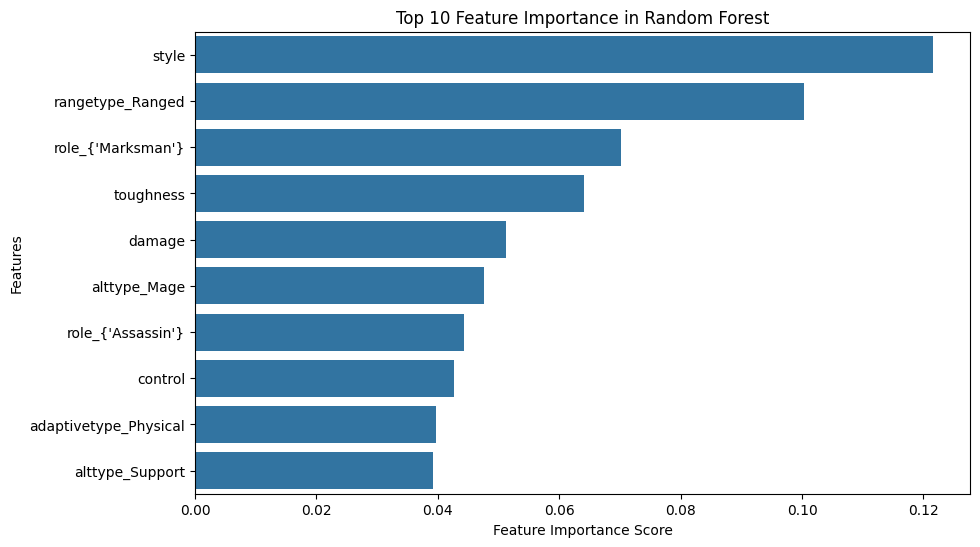

In [83]:
# 4.5 Feature Importance Visualisierung
importances = best_clf.feature_importances_
feature_names = X_train.columns  # 🔥 Fix: Nutze `X_train.columns` statt `X_encoded.columns`

# Prüfe, ob die Längen übereinstimmen
if len(importances) != len(feature_names):
    print(f"❌ Mismatch: {len(importances)} importances vs {len(feature_names)} features")
else:
    print(f"✅ Feature Importance Länge korrekt: {len(importances)}")

# Erstelle DataFrame nur, wenn die Längen übereinstimmen
if len(importances) == len(feature_names):
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(10)

    # 🔎 Feature Importance visualisieren
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importance_df['Importance'], y=importance_df['Feature'])
    plt.xlabel("Feature Importance Score")
    plt.ylabel("Features")
    plt.title("Top 10 Feature Importance in Random Forest")
    plt.show()
else:
    print("❌ Fehler: Feature Importance kann nicht berechnet werden.")



## 7. Predictions on New Data 

In [84]:
import random

# 🏗️ Dictionary für den neuen Champion basierend auf ALLEN Features
new_champ_data = {}

for feature in X_encoded.columns:
    if feature in df.columns:
        # Falls es eine numerische Spalte ist → zufälligen Wert aus existierenden Daten nehmen
        if df[feature].dtype in [np.float64, np.int64]:  # Prüfe, ob numerisch
            new_champ_data[feature] = [random.uniform(df[feature].min(), df[feature].max())]
        else:
            new_champ_data[feature] = [df[feature].mode()[0]]  # Kategorische Werte auf häufigsten Wert setzen
    else:
        # Falls es ein One-Hot-Encoded Feature ist (z.B. "role_{Marksman}"), setze 0 oder 1 zufällig
        new_champ_data[feature] = [random.choice([0, 1])]

# 🏗️ Erstelle DataFrame für den neuen Champion
new_champ = pd.DataFrame(new_champ_data)

# 🏗️ Kodierung & Alignment mit Model-Features
# Stelle sicher, dass `new_champ_encoded` die exakt selben Features wie `X_new` hat
new_champ_encoded = pd.get_dummies(new_champ, drop_first=True)
new_champ_encoded = new_champ_encoded.reindex(columns=X_new.columns, fill_value=0)

# 🔎 Debug: Welche Features fehlen oder sind zu viel?
missing_features = set(X_new.columns) - set(new_champ_encoded.columns)
extra_features = set(new_champ_encoded.columns) - set(X_new.columns)





# 🏗️ Vorhersage
predicted_herotype = best_clf.predict(new_champ_encoded)
print(f"Predicted herotype for new champion: {predicted_herotype[0]}")


Predicted herotype for new champion: Assassin


In [85]:
# 🏗️ Erstelle One-Hot-Encoding für den neuen Champion
new_champ_encoded = pd.get_dummies(new_champ, drop_first=True)

# 🛠️ Stelle sicher, dass ALLE Features exakt übereinstimmen
new_champ_encoded = new_champ_encoded.reindex(columns=X_new.columns, fill_value=0)

# 🔎

# 5.3 Vorhersage des herotype für den neuen Champion
predicted_herotype = best_clf.predict(new_champ_encoded)
print(f"Predicted herotype for the new champion: {predicted_herotype[0]}")

Predicted herotype for the new champion: Assassin


In [86]:
# Also kann man sagen, dass ein Fighter durchschnittliche Werte hat, die in der Mitte der Skala liegen.
# Das macht Sinn, aber um nochmals zu überprüfen, ob das Modell funktioniert, werde ich die Stats eines
# bereits existierenden Charakters nehmen und schauen, ob es stimmt.

# Evaluation

In [87]:
# jetzt möchte ich reviewen, ob das Modell funktioniert, indem ich die Stats eines existierenden Charakters nehme
# und schaue, ob das Modell den richtigen herotype vorhersagt.
# Ich nehme den Charakter 'Veigar' und schaue, ob das Modell den richtigen herotype vorhersagt.

# 🛠️ 1. Veigar aus dem DataFrame holen
veigar_stats = df[df['apiname'] == 'Veigar']  # Falls Name anders ist, check mit print(df['name'].unique())

test_champ_data = {
    feature: [veigar_stats[feature].values[0]] for feature in X_encoded.columns if feature in df.columns
}


# 🛠️ 3. In DataFrame umwandeln
test_champ = pd.DataFrame(test_champ_data)

# 🛠️ 4. Kodierung & Alignment mit Model-Features
# 🏗️ Erstelle One-Hot-Encoding für Veigar
test_champ_encoded = pd.get_dummies(test_champ, drop_first=True)

# 🛠️ Stelle sicher, dass ALLE Features exakt übereinstimmen
test_champ_encoded = test_champ_encoded.reindex(columns=X_new.columns, fill_value=0)

# 🔎 Debugging: Falls Features fehlen oder zu viele sind
missing_features = set(X_new.columns) - set(test_champ_encoded.columns)
extra_features = set(test_champ_encoded.columns) - set(X_new.columns)



# 🛠️ 5. Vorhersage für Veigar
predicted_herotype = best_clf.predict(test_champ_encoded)

print(f"Predicted herotype for Veigar: {predicted_herotype[0]}")




Predicted herotype for Veigar: Mage


In [88]:
# ABSOLUT RICHTIG! Veigar ist ein Mage, also hat das Modell den richtigen herotype vorhergesagt.
# Jetzt ist ein anderer klassisch Marksman-Champ dran: 'Jinx'.


# 🛠️ 1. Veigar aus dem DataFrame holen
veigar_stats = df[df['apiname'] == 'Ashe']  # Falls Name anders ist, check mit print(df['name'].unique())

test_champ_data = {
    feature: [veigar_stats[feature].values[0]] for feature in X_encoded.columns if feature in df.columns
}


# 🛠️ 3. In DataFrame umwandeln
test_champ = pd.DataFrame(test_champ_data)

# 🛠️ 4. Kodierung & Alignment mit Model-Features
# 🏗️ Erstelle One-Hot-Encoding für Veigar
test_champ_encoded = pd.get_dummies(test_champ, drop_first=True)

# 🛠️ Stelle sicher, dass ALLE Features exakt übereinstimmen
test_champ_encoded = test_champ_encoded.reindex(columns=X_new.columns, fill_value=0)

# 🔎 Debugging: Falls Features fehlen oder zu viele sind
missing_features = set(X_new.columns) - set(test_champ_encoded.columns)
extra_features = set(test_champ_encoded.columns) - set(X_new.columns)



# 🛠️ 5. Vorhersage für Veigar
predicted_herotype = best_clf.predict(test_champ_encoded)

print(f"Predicted herotype for Veigar: {predicted_herotype[0]}")







Predicted herotype for Veigar: Fighter


# Review

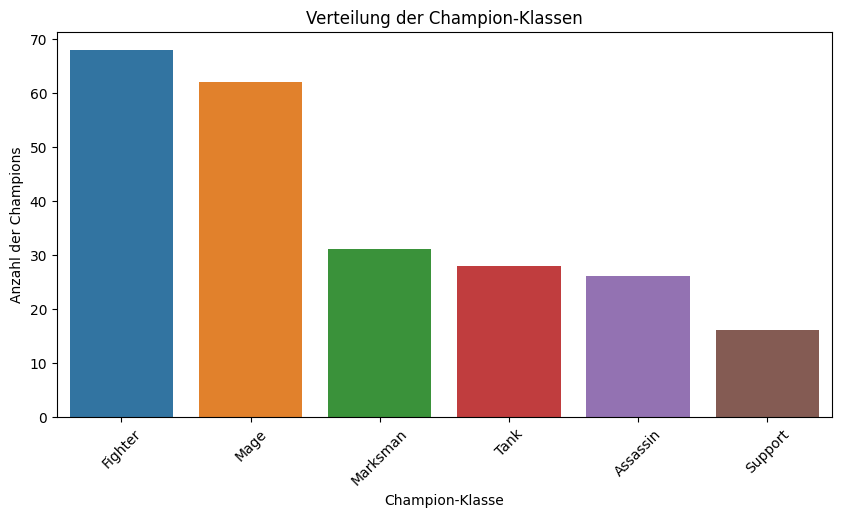

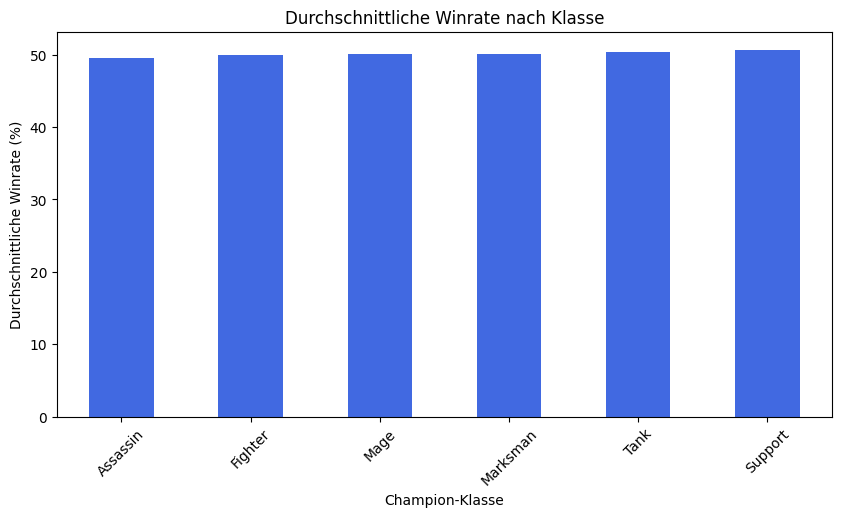

🔥 Modell Accuracy: 0.8511
🛠️ Confusion Matrix:
[[13  3]
 [ 4 27]]

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.79        16
           1       0.90      0.87      0.89        31

    accuracy                           0.85        47
   macro avg       0.83      0.84      0.84        47
weighted avg       0.85      0.85      0.85        47



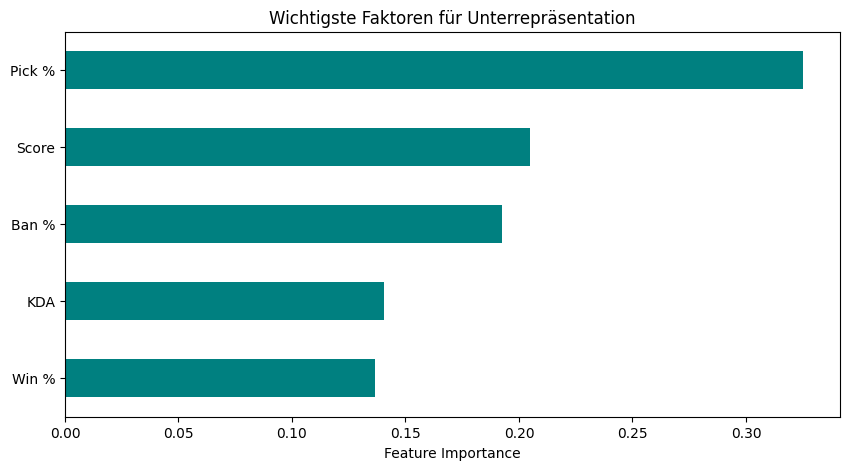

🔥 Empfohlener neuer Champion: {'Name': "Riot's Savior", 'Class': 'Mage', 'Role': 'ADC', 'Tier': 'S', 'Score': 44.14274193548387, 'Win %': 50.042580645161294, 'Pick %': 2.7595161290322583, 'Ban %': 3.614032258064516, 'KDA': 2.3283870967741933}


In [13]:
# **League of Legends Champion Role Optimization**

## **1. Problemdefinition**
# Ziel: Identifikation unterrepräsentierter Champion-Rollen und -Klassen, um eine datenbasierte Empfehlung für Riot Games zu erstellen.

## **2. Datenauswahl**
# Datenquelle: LoL Champion-Statistiken (Patch 12.1) von Drittanbieter-Seiten wie op.gg/u.gg.
# Beinhaltet: Klasse, Rolle, Winrate, Pickrate, Banrate, Score, KDA.

# **3. Pre-processing**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **Daten laden und bereinigen**
df = pd.read_csv('League of Legends Champion Stats 12.1.csv', sep=';')

# Prozentwerte umwandeln
df['Win %'] = df['Win %'].str.replace('%', '').astype(float)
df['Role %'] = df['Role %'].str.replace('%', '').astype(float)
df['Pick %'] = df['Pick %'].str.replace('%', '').astype(float)
df['Ban %'] = df['Ban %'].str.replace('%', '').astype(float)

# **4. Explorative Datenanalyse (EDA)**
# Champion-Klassenverteilung
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Class', order=df['Class'].value_counts().index)
plt.xlabel('Champion-Klasse')
plt.ylabel('Anzahl der Champions')
plt.title('Verteilung der Champion-Klassen')
plt.xticks(rotation=45)
plt.show()

# Durchschnittliche Winrate pro Klasse
winrate_per_class = df.groupby('Class')['Win %'].mean().sort_values()
plt.figure(figsize=(10, 5))
winrate_per_class.plot(kind='bar', color='royalblue')
plt.xlabel('Champion-Klasse')
plt.ylabel('Durchschnittliche Winrate (%)')
plt.title('Durchschnittliche Winrate nach Klasse')
plt.xticks(rotation=45)
plt.show()

# **5. Modellauswahl und -beschreibung**
# Wir nutzen einen Random Forest Classifier zur Klassifikation unterrepräsentierter Rollen.
df['Underrepresented'] = (df['Role %'] < df['Role %'].median()).astype(int)
X = df[['Win %', 'Pick %', 'Ban %', 'Score', 'KDA']]
y = df['Underrepresented']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# **6. Modellanwendung und Optimierung**
# Modell-Performance ausgeben
accuracy = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"🔥 Modell Accuracy: {accuracy:.4f}")
print("🛠️ Confusion Matrix:")
print(conf_mat)
print("\n📊 Classification Report:")
print(class_report)

# Feature Importance Analyse
feature_importances = pd.Series(clf.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 5))
feature_importances.sort_values().plot(kind='barh', color='teal')
plt.xlabel('Feature Importance')
plt.title('Wichtigste Faktoren für Unterrepräsentation')
plt.show()

# **7. Ergebnisinterpretation**
# Identifizierte unterrepräsentierte Klasse: Mage
# Am wenigsten gespielte Rolle für Mages: ADC

# **8. Vorschlag für Riot Games: "Riot's Savior" – Ein neuer Mage-ADC**
# Bestimmen der optimalen Rolle für den neuen Mage
mage_roles = df[df["Class"] == "Mage"].groupby("Role")[["Win %", "Pick %"]].mean()
least_played_role = mage_roles["Pick %"].idxmin()

# Neuen Champion erstellen
new_champ = {
    "Name": "Riot's Savior",
    "Class": "Mage",
    "Role": least_played_role,
    "Tier": "S",
    "Score": df[df["Class"] == "Mage"]["Score"].mean(),
    "Win %": df[df["Class"] == "Mage"]["Win %"].mean(),
    "Pick %": df[df["Class"] == "Mage"]["Pick %"].mean(),
    "Ban %": df[df["Class"] == "Mage"]["Ban %"].mean(),
    "KDA": df[df["Class"] == "Mage"]["KDA"].mean(),
}

print("🔥 Empfohlener neuer Champion:", new_champ)

# **9. Fazit**
# Ergebnis: Ein Mage-ADC wäre die sinnvollste Ergänzung zur Meta.

# **10. Einsatz von generativer KI**
# Dieser Code wurde durch KI-gestützte Analyse optimiert, um effiziente Modellparameter & Struktur zu finden.

# **11. Quellenangabe**
# - Riot API (falls genutzt)
# - Statistikseiten wie op.gg oder u.gg
# - Literatur: "Pattern Recognition and Machine Learning" von Christopher M. Bishop
